In [25]:
import os
from PIL import Image
import pytesseract
from paddleocr import PaddleOCR
import time
import pandas as pd

# Initialize OCR
ocr = PaddleOCR(use_angle_cls=True, lang='en')

# Set path
image_dir = "/root/pytesseract/testData_drivers"
image_names = sorted([f for f in os.listdir(image_dir) if f.endswith('.jpg')])

# Result storage
results = []

for img_name in image_names:
    img_path = os.path.join(image_dir, img_name)
    img = Image.open(img_path)

    # Tesseract OCR
    start = time.time()
    tess_data = pytesseract.image_to_data(img, output_type=pytesseract.Output.DICT)
    tess_time = time.time() - start
    tess_confs = [int(c) for c in tess_data['conf'] if str(c) != '-1']

    #tess_confs = [int(c) for c in tess_data['conf'] if c != '-1']
    tess_chars = sum([len(w) for w in tess_data['text'] if w.strip() != ''])
    tess_avg_conf = sum(tess_confs) / len(tess_confs)/100 if tess_confs else 0
    


    # PaddleOCR
    start = time.time()
    result_paddle = ocr.ocr(img_path, cls=True)
    paddle_time = time.time() - start
    paddle_confs = [line[1][1] for line in result_paddle[0]]
    paddle_chars = sum([len(line[1][0].replace(" ", "")) for line in result_paddle[0]])
    paddle_avg_conf = sum(paddle_confs) / len(paddle_confs) if paddle_confs else 0

    # Append to results
    results.append({
        'Image': img_name,
        'Tesseract_Chars': tess_chars,
        'Tesseract_Conf': round(tess_avg_conf, 2),
        'Tesseract_Time': round(tess_time, 2),
        'PaddleOCR_Chars': paddle_chars,
        'PaddleOCR_Conf': round(paddle_avg_conf, 2),
        'PaddleOCR_Time': round(paddle_time, 2),
    })

# Convert to DataFrame
df = pd.DataFrame(results)


[2025/05/10 14:47:56] ppocr DEBUG: Namespace(help='==SUPPRESS==', use_gpu=False, use_xpu=False, use_npu=False, use_mlu=False, use_gcu=False, ir_optim=True, use_tensorrt=False, min_subgraph_size=15, precision='fp32', gpu_mem=500, gpu_id=0, image_dir=None, page_num=0, det_algorithm='DB', det_model_dir='/root/.paddleocr/whl/det/en/en_PP-OCRv3_det_infer', det_limit_side_len=960, det_limit_type='max', det_box_type='quad', det_db_thresh=0.3, det_db_box_thresh=0.6, det_db_unclip_ratio=1.5, max_batch_size=10, use_dilation=False, det_db_score_mode='fast', det_east_score_thresh=0.8, det_east_cover_thresh=0.1, det_east_nms_thresh=0.2, det_sast_score_thresh=0.5, det_sast_nms_thresh=0.2, det_pse_thresh=0, det_pse_box_thresh=0.85, det_pse_min_area=16, det_pse_scale=1, scales=[8, 16, 32], alpha=1.0, beta=1.0, fourier_degree=5, rec_algorithm='SVTR_LCNet', rec_model_dir='/root/.paddleocr/whl/rec/en/en_PP-OCRv4_rec_infer', rec_image_inverse=True, rec_image_shape='3, 48, 320', rec_batch_num=6, max_text_l

In [26]:
df

,Image,Tesseract_Chars,Tesseract_Conf,Tesseract_Time,PaddleOCR_Chars,PaddleOCR_Conf,PaddleOCR_Time
0,Driver_01.jpg,26,0.39,0.81,256,0.94,14.35
1,Driver_02.jpg,35,0.59,0.16,251,0.94,2.37
2,Driver_03.jpg,157,0.75,1.21,201,0.90,1.62
3,Driver_04.jpg,126,0.30,0.28,249,0.90,17.27
4,Driver_05.jpg,154,0.76,0.37,200,0.91,1.97
5,Driver_06.jpg,27,0.59,0.18,240,0.93,1.63
6,Driver_07.jpg,123,0.51,0.31,246,0.90,1.60
7,Driver_08.jpg,338,0.70,0.47,302,0.96,2.04
8,Driver_09.jpg,282,0.58,0.38,264,0.95,1.57
9,Driver_10.jpg,213,0.70,0.39,220,0.94,1.70


In [ ]:
import numpy as np
print("All confs:", tess_data['conf'])
print("Filtered confs:", tess_confs)
print("Average (0–1):", np.mean(tess_confs) / 100)


All confs: [-1, -1, -1, -1, 96, -1, -1, -1, 95, -1, -1, -1, 95, -1, 95, -1, -1, -1, 68, -1, 0, 38, 44, -1, 93, 22, 31, -1, -1, -1, 28, 88, 83, 87, 54, 5, 0, -1, 25, 89, 54, -1, 95, 74, -1, -1, -1, 52, 51, -1, -1, -1, 0, 64, 58, 46, -1, -1, 52, 95, 30, -1, -1, 45, 65, 0, 22, 0, -1, -1, 59, 0, -1, 67, 31]
Filtered confs: [96, 95, 95, 95, 68, 0, 38, 44, 93, 22, 31, 28, 88, 83, 87, 54, 5, 0, 25, 89, 54, 95, 74, 52, 51, 0, 64, 58, 46, 52, 95, 30, 45, 65, 0, 22, 0, 59, 0, 67, 31]
Average (0–1): 0.511219512195122


In [12]:
import numpy as np
from statistics import mode

# Replace in your loop after tess_confs is calculated:
tess_avg_conf = sum(tess_confs) / len(tess_confs) / 100 if tess_confs else 0
tess_median_conf = np.median(tess_confs) / 100 if tess_confs else 0
tess_mode_conf = mode(tess_confs) / 100 if tess_confs else 0
tess_std_conf = np.std(tess_confs) / 100 if tess_confs else 0


In [ ]:
# If your data is in a DataFrame called df
df.to_csv('ocr_driver_comparison.csv', index=False)


: 

In [14]:
# --- Load Image ---
image_path = 'testData_drivers/Driver_08.jpg'
img = Image.open(image_path).convert('RGB')

# --- PyTesseract ---
tess_data = pytesseract.image_to_data(img, output_type=pytesseract.Output.DICT)
tess_text = [t for t in tess_data['text'] if t.strip()]
tess_conf = [int(c) for c in tess_data['conf'] if c != '-1']
avg_conf_tess = sum(tess_conf)/len(tess_conf)/100 if tess_conf else 0

# --- PaddleOCR ---
result_paddle = ocr.ocr(image_path, cls=True)
paddle_text = [line[1][0] for line in result_paddle[0]]
paddle_conf = [line[1][1] for line in result_paddle[0]]
avg_conf_paddle = sum(paddle_conf)/len(paddle_conf) if paddle_conf else 0

# --- Output Summary ---
print("Tesseract Output:")
for t in tess_text: print(t)
print(f"Tesseract Avg. Confidence: {avg_conf_tess:.2f}")
print(f"Tesseract Characters: {sum(len(t) for t in tess_text)}")

print("\nPaddleOCR Output:")
for t in paddle_text: print(t)
print(f"PaddleOCR Avg. Confidence: {avg_conf_paddle:.2f}")
print(f"PaddleOCR Characters: {sum(len(t.replace(' ', '')) for t in paddle_text)}")


[2025/05/08 15:09:08] ppocr DEBUG: dt_boxes num : 36, elapsed : 0.9965705871582031
[2025/05/08 15:09:08] ppocr DEBUG: cls num  : 36, elapsed : 0.2525968551635742
[2025/05/08 15:09:13] ppocr DEBUG: rec_res num  : 36, elapsed : 5.163427114486694
Tesseract Output:
m
LIMITED
TERM
Whe
MARYLAND:
.
Commercial
Driver's
License
(cot)
st
2
“6
V/;
Customer
identifier
¢
MD-10272323672;
|
Family
name
.
:
SWE
\
LATIPOV
=
|
eel
Given
nanies
<
a
.
2
MUKHAMMADJON
—
Address
IBN
1802
SNOW
MEADOW
LN
UNIT
302
BALTIMORE
MD
21209-5843
ri
Die
of
birth)
Sex
Height
Weight
Date
of
exp
)
)
240490B39
iy
10/1998
M
5'-07"
158
06/26/2024
hy
TS6
Classifications
Endorsements
Date
of
issue
QF
Za
A
04/24/2023
=
py}
Tesseract Avg. Confidence: 0.41
Tesseract Characters: 347

PaddleOCR Output:
MARYLAND
LIMITED TERM
Commercial Driver's License
CDL
Customer identifier
03/10/1998
MD-10272323672
Family name
240490B39
LATIPOV
Given names
MUKHAMMADJON
Address
1802 SNOWMEADOWLNUNIT302
BALTIMOREMD21209-5843
Dage of birth
Sex
Heighe

[2025/05/08 15:09:37] ppocr DEBUG: Namespace(help='==SUPPRESS==', use_gpu=False, use_xpu=False, use_npu=False, use_mlu=False, use_gcu=False, ir_optim=True, use_tensorrt=False, min_subgraph_size=15, precision='fp32', gpu_mem=500, gpu_id=0, image_dir=None, page_num=0, det_algorithm='DB', det_model_dir='/root/.paddleocr/whl/det/en/en_PP-OCRv3_det_infer', det_limit_side_len=960, det_limit_type='max', det_box_type='quad', det_db_thresh=0.3, det_db_box_thresh=0.6, det_db_unclip_ratio=1.5, max_batch_size=10, use_dilation=False, det_db_score_mode='fast', det_east_score_thresh=0.8, det_east_cover_thresh=0.1, det_east_nms_thresh=0.2, det_sast_score_thresh=0.5, det_sast_nms_thresh=0.2, det_pse_thresh=0, det_pse_box_thresh=0.85, det_pse_min_area=16, det_pse_scale=1, scales=[8, 16, 32], alpha=1.0, beta=1.0, fourier_degree=5, rec_algorithm='SVTR_LCNet', rec_model_dir='/root/.paddleocr/whl/rec/en/en_PP-OCRv4_rec_infer', rec_image_inverse=True, rec_image_shape='3, 48, 320', rec_batch_num=6, max_text_l

[2025/05/08 15:09:40] ppocr DEBUG: dt_boxes num : 36, elapsed : 0.44048261642456055
[2025/05/08 15:09:40] ppocr DEBUG: cls num  : 36, elapsed : 0.2921273708343506
[2025/05/08 15:09:44] ppocr DEBUG: rec_res num  : 36, elapsed : 3.5218727588653564


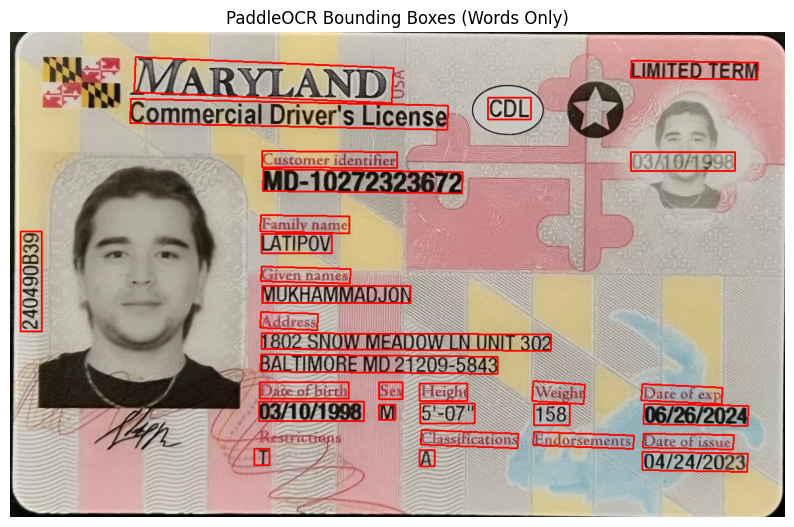

In [15]:
from paddleocr import PaddleOCR, draw_ocr
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np

# Initialize PaddleOCR
ocr = PaddleOCR(use_angle_cls=True, lang='en')

# Load and prepare image
image_path = 'testData_drivers/Driver_08.jpg'  # change as needed
image = Image.open(image_path).convert('RGB')

# Run OCR
result = ocr.ocr(image_path, cls=True)

# Extract only boxes
boxes = [line[0] for line in result[0]]

# Draw boxes (no text or scores to avoid font error)
boxed_image = draw_ocr(np.array(image), boxes)

# Display
plt.figure(figsize=(10, 10))
plt.imshow(boxed_image)
plt.axis('off')
plt.title("PaddleOCR Bounding Boxes (Words Only)")
plt.show()



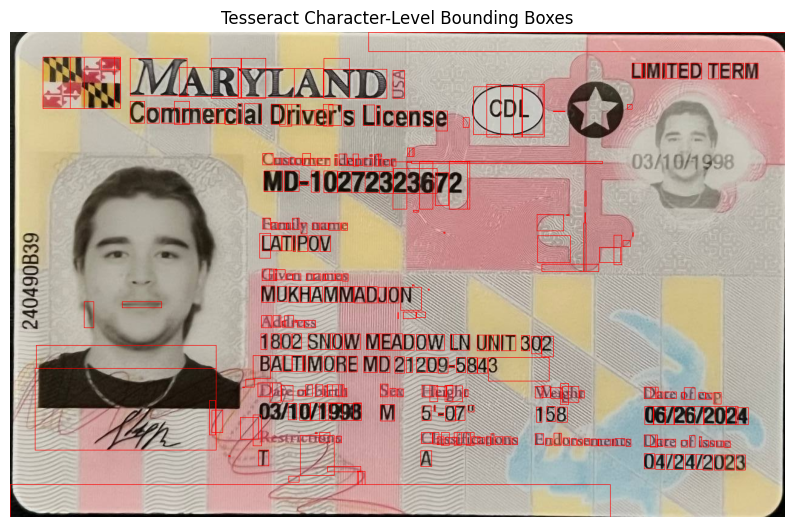

In [16]:
from PIL import Image, ImageDraw
import pytesseract
import numpy as np
import matplotlib.pyplot as plt

# Load image
image_path = 'testData_drivers/Driver_08.jpg'  # change to your actual path
image = Image.open(image_path).convert('RGB')

# Run Tesseract to get bounding boxes
boxes = pytesseract.image_to_boxes(image)

# Draw character-level boxes
draw = ImageDraw.Draw(image)
for box in boxes.splitlines():
    b = box.split()
    char, x1, y1, x2, y2 = b[0], int(b[1]), int(b[2]), int(b[3]), int(b[4])
    # Flip y-axis (Pillow uses top-left origin; Tesseract uses bottom-left)
    draw.rectangle([x1, image.height - y2, x2, image.height - y1], outline='red')

# Convert to numpy and plot
img_np = np.asarray(image)
plt.figure(figsize=(10, 8))
plt.imshow(img_np)
plt.axis('off')
plt.title('Tesseract Character-Level Bounding Boxes')
plt.show()


In [17]:
# Standard Deviation of Confidence
std_conf_tesseract = df['Tesseract_Conf'].std()
std_conf_paddle = df['PaddleOCR_Conf'].std()

# Standard Deviation of Time
std_time_tesseract = df['Tesseract_Time'].std()
std_time_paddle = df['PaddleOCR_Time'].std()

# Print the results
print(f"Standard Deviation of Tesseract Confidence: {std_conf_tesseract:.2f}")
print(f"Standard Deviation of PaddleOCR Confidence: {std_conf_paddle:.2f}")
print(f"Standard Deviation of Tesseract Time: {std_time_tesseract:.2f}")
print(f"Standard Deviation of PaddleOCR Time: {std_time_paddle:.2f}")


Standard Deviation of Tesseract Confidence: 0.18
Standard Deviation of PaddleOCR Confidence: 0.03
Standard Deviation of Tesseract Time: 0.12
Standard Deviation of PaddleOCR Time: 1.29


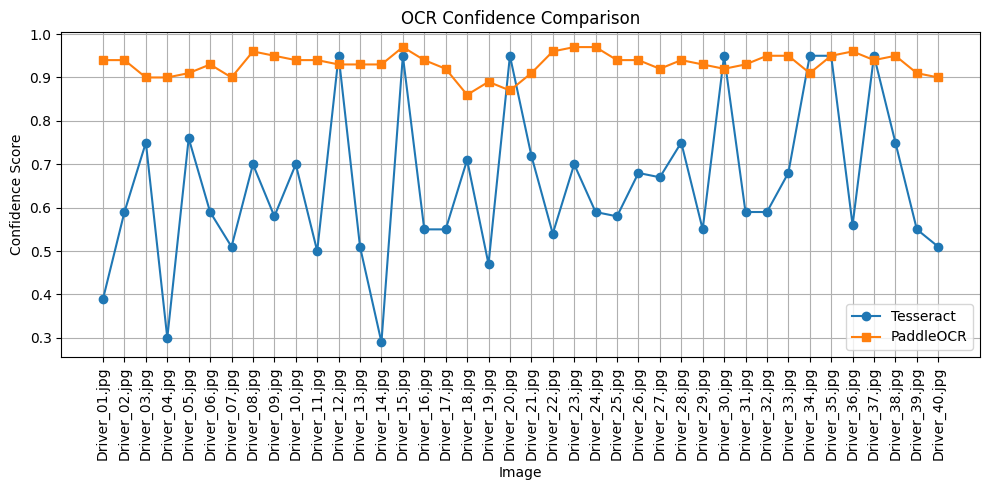

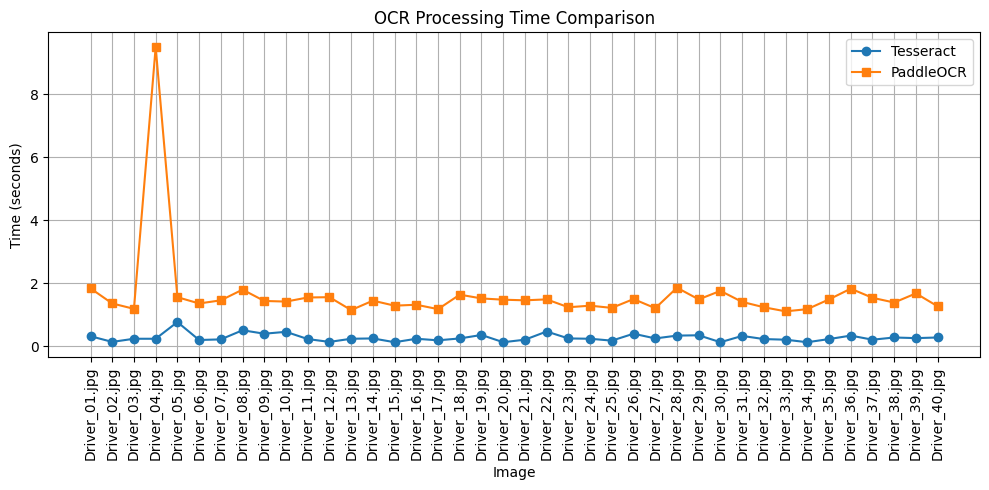

In [18]:
import matplotlib.pyplot as plt

# --- Plot 1: Confidence (Accuracy) Comparison ---
plt.figure(figsize=(10, 5))
plt.plot(df['Image'], df['Tesseract_Conf'], label='Tesseract', marker='o')
plt.plot(df['Image'], df['PaddleOCR_Conf'], label='PaddleOCR', marker='s')
plt.xlabel('Image')
plt.ylabel('Confidence Score')
plt.title('OCR Confidence Comparison')
plt.xticks(rotation=90)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# --- Plot 2: Processing Time Comparison ---
plt.figure(figsize=(10, 5))
plt.plot(df['Image'], df['Tesseract_Time'], label='Tesseract', marker='o')
plt.plot(df['Image'], df['PaddleOCR_Time'], label='PaddleOCR', marker='s')
plt.xlabel('Image')
plt.ylabel('Time (seconds)')
plt.title('OCR Processing Time Comparison')
plt.xticks(rotation=90)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


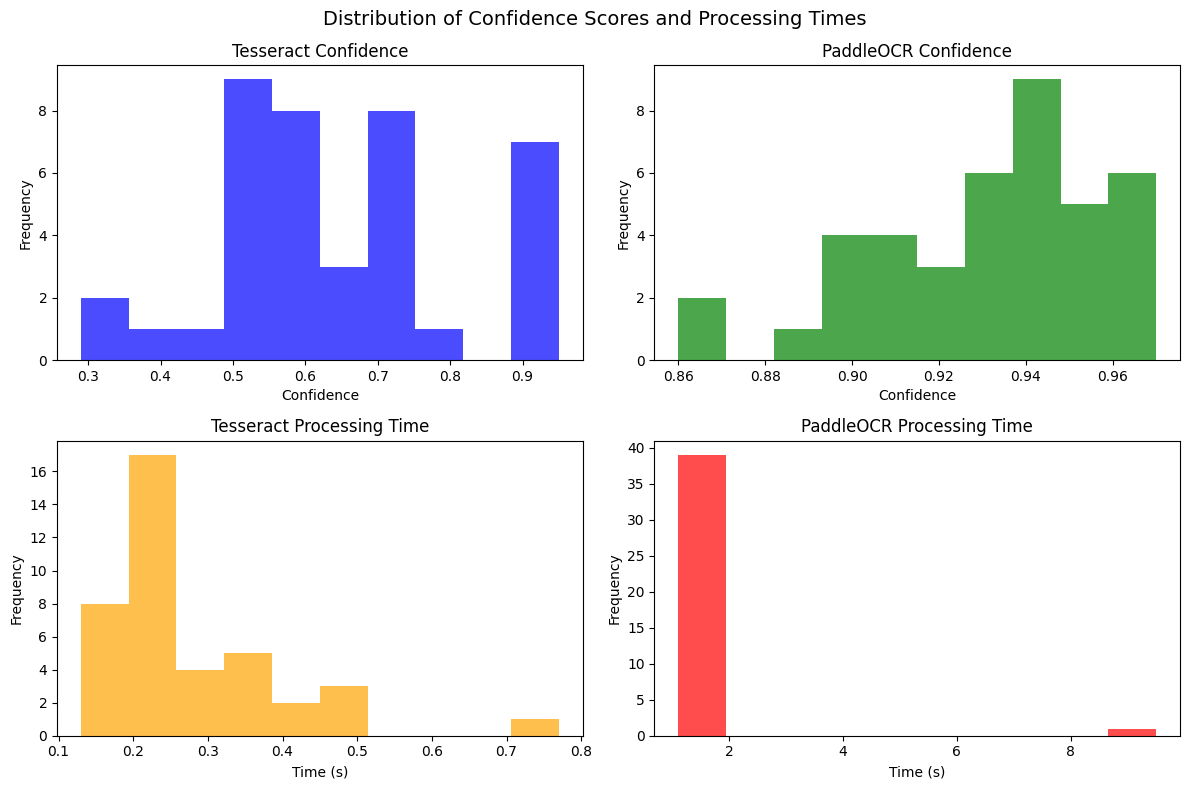

In [19]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the CSV file
df = pd.read_csv("ocr_driver_comparison.csv")

# Set up subplots
fig, axs = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle("Distribution of Confidence Scores and Processing Times", fontsize=14)

# Histogram for Tesseract Confidence
axs[0, 0].hist(df['Tesseract_Conf'], bins=10, color='blue', alpha=0.7)
axs[0, 0].set_title('Tesseract Confidence')
axs[0, 0].set_xlabel('Confidence')
axs[0, 0].set_ylabel('Frequency')

# Histogram for PaddleOCR Confidence
axs[0, 1].hist(df['PaddleOCR_Conf'], bins=10, color='green', alpha=0.7)
axs[0, 1].set_title('PaddleOCR Confidence')
axs[0, 1].set_xlabel('Confidence')
axs[0, 1].set_ylabel('Frequency')

# Histogram for Tesseract Time
axs[1, 0].hist(df['Tesseract_Time'], bins=10, color='orange', alpha=0.7)
axs[1, 0].set_title('Tesseract Processing Time')
axs[1, 0].set_xlabel('Time (s)')
axs[1, 0].set_ylabel('Frequency')

# Histogram for PaddleOCR Time
axs[1, 1].hist(df['PaddleOCR_Time'], bins=10, color='red', alpha=0.7)
axs[1, 1].set_title('PaddleOCR Processing Time')
axs[1, 1].set_xlabel('Time (s)')
axs[1, 1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()


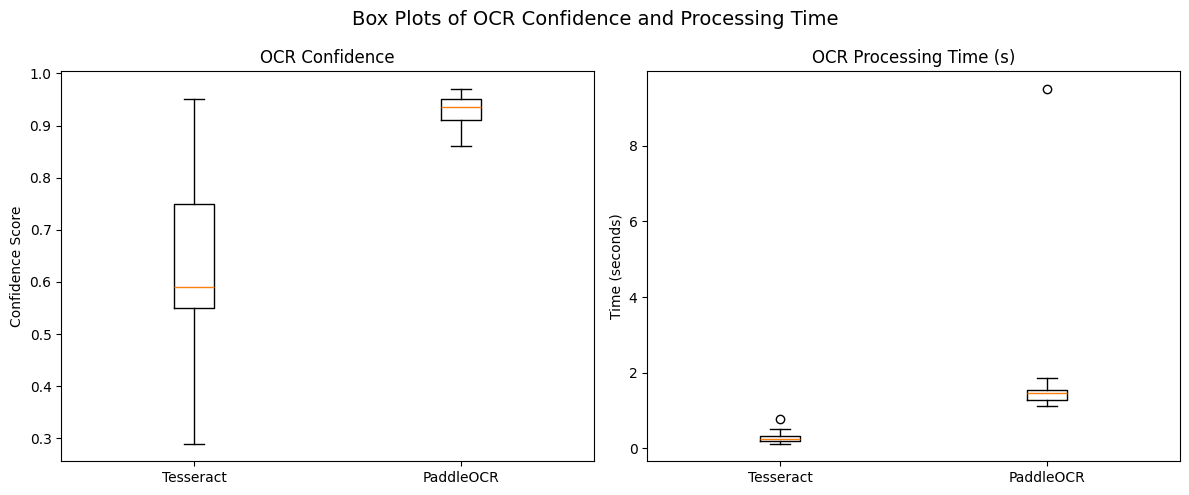

In [20]:
import matplotlib.pyplot as plt

# Set up subplots
fig, axs = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("Box Plots of OCR Confidence and Processing Time", fontsize=14)

# Boxplot for Confidence
axs[0].boxplot([df['Tesseract_Conf'], df['PaddleOCR_Conf']], labels=['Tesseract', 'PaddleOCR'])
axs[0].set_title('OCR Confidence')
axs[0].set_ylabel('Confidence Score')

# Boxplot for Time
axs[1].boxplot([df['Tesseract_Time'], df['PaddleOCR_Time']], labels=['Tesseract', 'PaddleOCR'])
axs[1].set_title('OCR Processing Time (s)')
axs[1].set_ylabel('Time (seconds)')

plt.tight_layout()
plt.show()


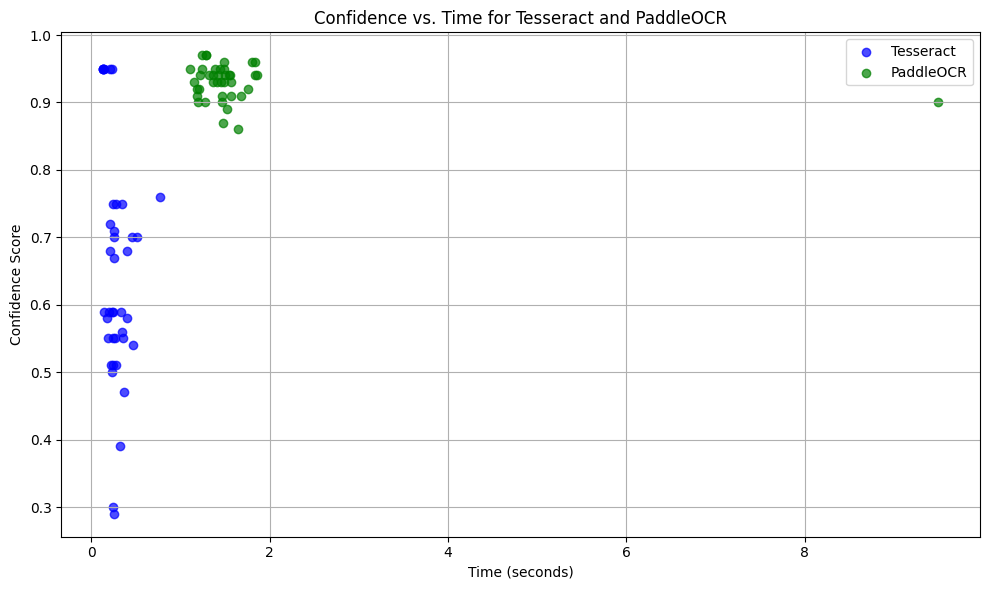

In [21]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.scatter(df['Tesseract_Time'], df['Tesseract_Conf'], color='blue', label='Tesseract', alpha=0.7)
plt.scatter(df['PaddleOCR_Time'], df['PaddleOCR_Conf'], color='green', label='PaddleOCR', alpha=0.7)

plt.title("Confidence vs. Time for Tesseract and PaddleOCR")
plt.xlabel("Time (seconds)")
plt.ylabel("Confidence Score")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [22]:
# Correlation for Tesseract
corr_tess = df['Tesseract_Conf'].corr(df['Tesseract_Time'])
print(f"Correlation (Tesseract - Confidence vs. Time): {round(corr_tess, 2)}")

# Correlation for PaddleOCR
corr_paddle = df['PaddleOCR_Conf'].corr(df['PaddleOCR_Time'])
print(f"Correlation (PaddleOCR - Confidence vs. Time): {round(corr_paddle, 2)}")


Correlation (Tesseract - Confidence vs. Time): -0.2
Correlation (PaddleOCR - Confidence vs. Time): -0.19


In [23]:
pip install seaborn


Note: you may need to restart the kernel to use updated packages.


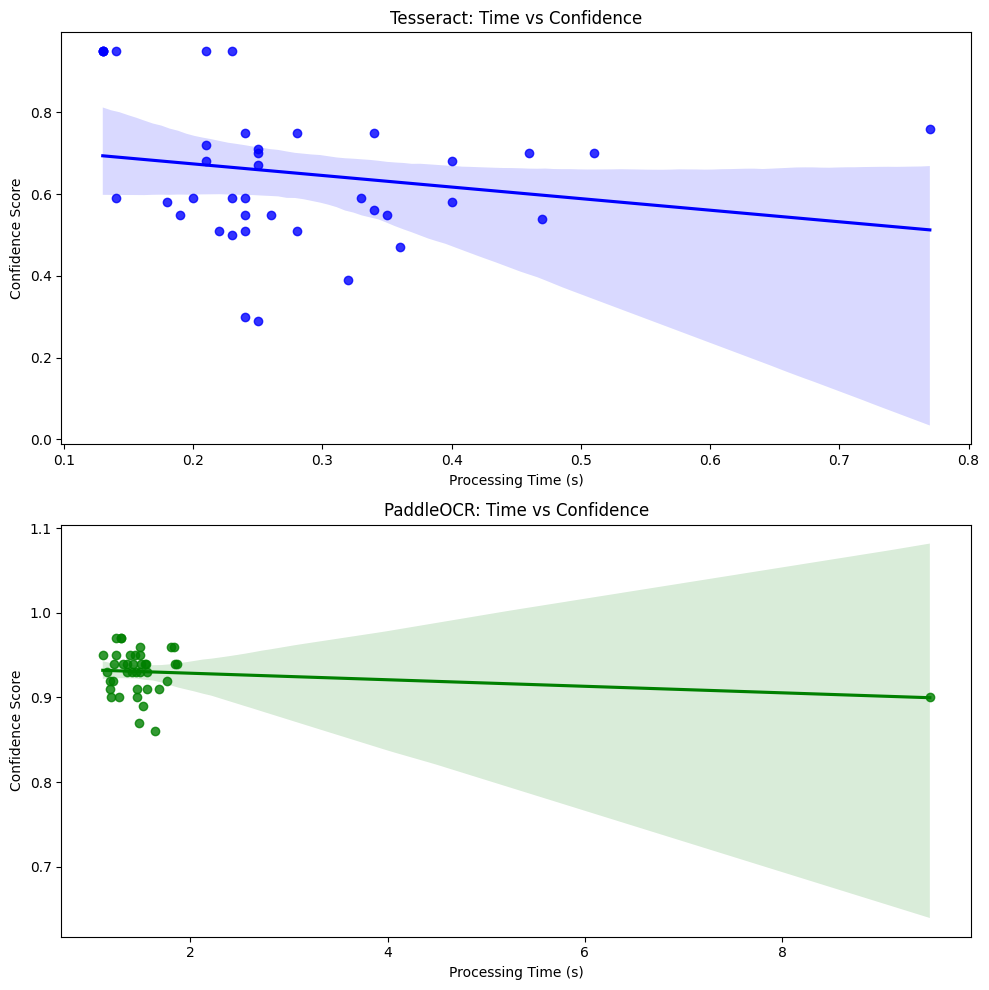

In [24]:
import seaborn as sns

# Set up the plot
fig, axes = plt.subplots(2, 1, figsize=(10, 10))

# Tesseract Regression
sns.regplot(ax=axes[0], x='Tesseract_Time', y='Tesseract_Conf', data=df, color='blue')
axes[0].set_title('Tesseract: Time vs Confidence')
axes[0].set_xlabel('Processing Time (s)')
axes[0].set_ylabel('Confidence Score')

# PaddleOCR Regression
sns.regplot(ax=axes[1], x='PaddleOCR_Time', y='PaddleOCR_Conf', data=df, color='green')
axes[1].set_title('PaddleOCR: Time vs Confidence')
axes[1].set_xlabel('Processing Time (s)')
axes[1].set_ylabel('Confidence Score')

plt.tight_layout()
plt.show()
